In [31]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import random
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import seaborn as sns
import pandas as pd
from skimage.feature import graycomatrix, graycoprops

In [3]:
base_dir = "../data_resized/"
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

MAX_IMAGES_PER_DATASET = 10000


### Statistics 

In [ ]:
def count_images_by_class(base_dir: str, valid_extensions: set):
    data = []
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if dataset_folder.is_dir():
            dataset_name = dataset_folder.name
            for class_folder in ['real', 'fake']:
                class_path = dataset_folder / class_folder
                if class_path.exists():
                    count = sum(
                        1 for file in class_path.iterdir()
                        if file.suffix.lower() in valid_extensions
                    )
                    data.append({
                        "dataset": dataset_name,
                        "class": class_folder,
                        "count": count
                    })

    df = pd.DataFrame(data)

    # percentage
    total_df = df.groupby("dataset")["count"].sum(
    ).reset_index().rename(columns={"count": "total"})
    df = df.merge(total_df, on="dataset")
    df["percentage"] = (df["count"] / df["total"] * 100).round(2)

    return df


def plot_class_distribution(df: pd.DataFrame):
    _, ax = plt.subplots(figsize=(8, 6))
    for dataset in df["dataset"].unique():
        subset = df[df["dataset"] == dataset]
        ax.bar(
            [f"{dataset}-{cls}" for cls in subset["class"]],
            subset["count"],
            label=dataset
        )

    ax.set_title("Image count (Real vs Fake)")
    ax.set_ylabel("Number of images")
    ax.set_xlabel("Dataset class")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


   dataset class  count   total  percentage
0      art  real  48259  107724       44.80
1      art  fake  59465  107724       55.20
2  animals  real  87933  149255       58.91
3  animals  fake  61322  149255       41.09
4    faces  real  70000  120959       57.87
5    faces  fake  50959  120959       42.13


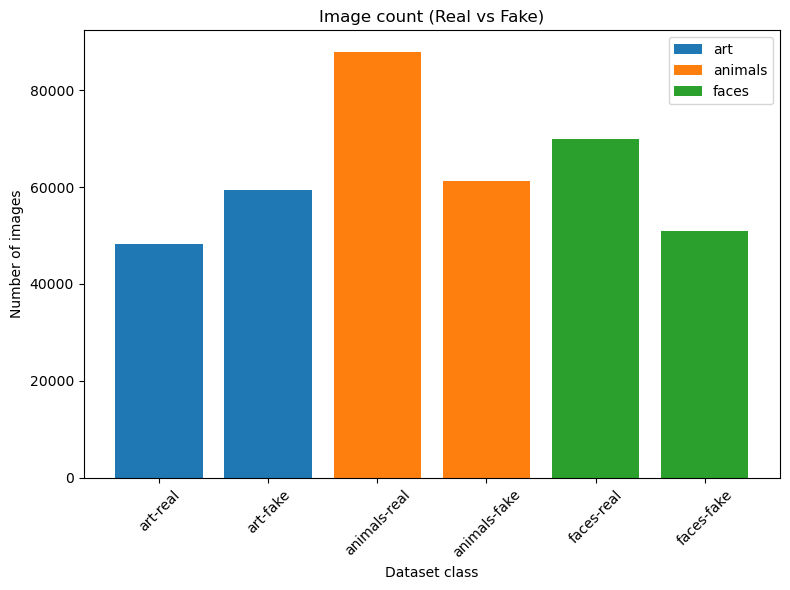

In [18]:
df = count_images_by_class(base_dir, valid_extensions)
print(df)
plot_class_distribution(df)

### Sample images

In [ ]:
def show_sample_images(base_dir: str, valid_extensions: set):
    """display 4 random real and 4 random fake images per dataset"""
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if not dataset_folder.is_dir():
            continue
        dataset_name = dataset_folder.name
        print(f"Dataset: {dataset_name}")
        _, axes = plt.subplots(2, 4, figsize=(12, 6))
        for row_idx, cls in enumerate(['real', 'fake']):
            class_path = dataset_folder / cls
            image_files = [f for f in class_path.iterdir(
            ) if f.suffix.lower() in valid_extensions]
            if not image_files:
                continue
            sampled = random.sample(image_files, min(4, len(image_files)))

            for col_idx, img_path in enumerate(sampled):
                img = cv2.imread(str(img_path))
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax = axes[row_idx, col_idx]
                ax.imshow(img_rgb)
                ax.set_title(f"{cls.capitalize()} #{col_idx+1}")
                ax.axis('off')

        plt.suptitle(f"Sample Images from {dataset_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

Dataset: art


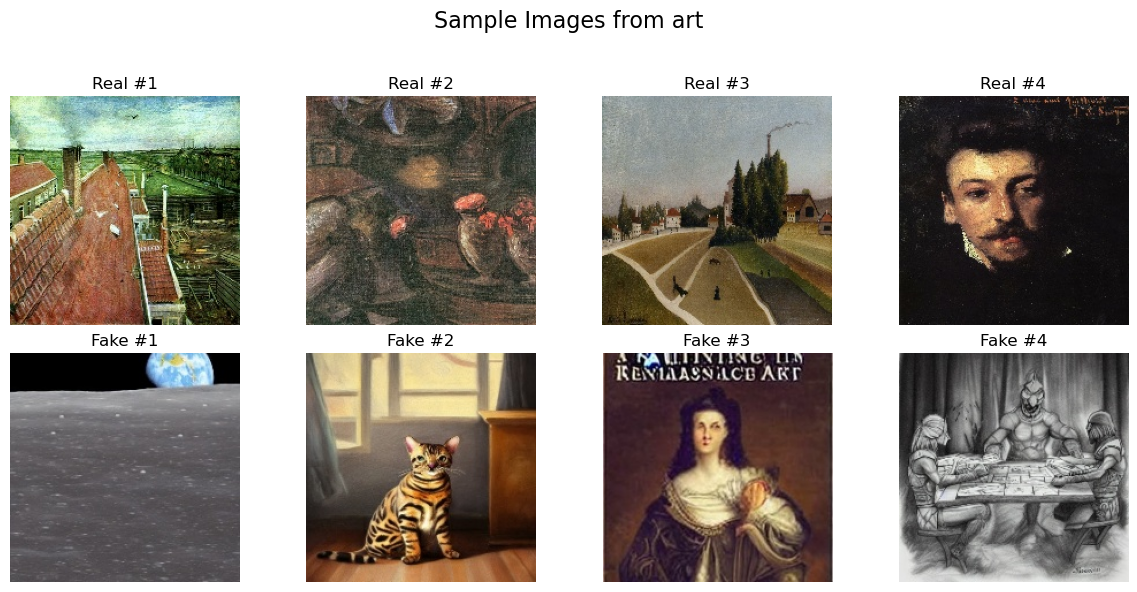

Dataset: animals


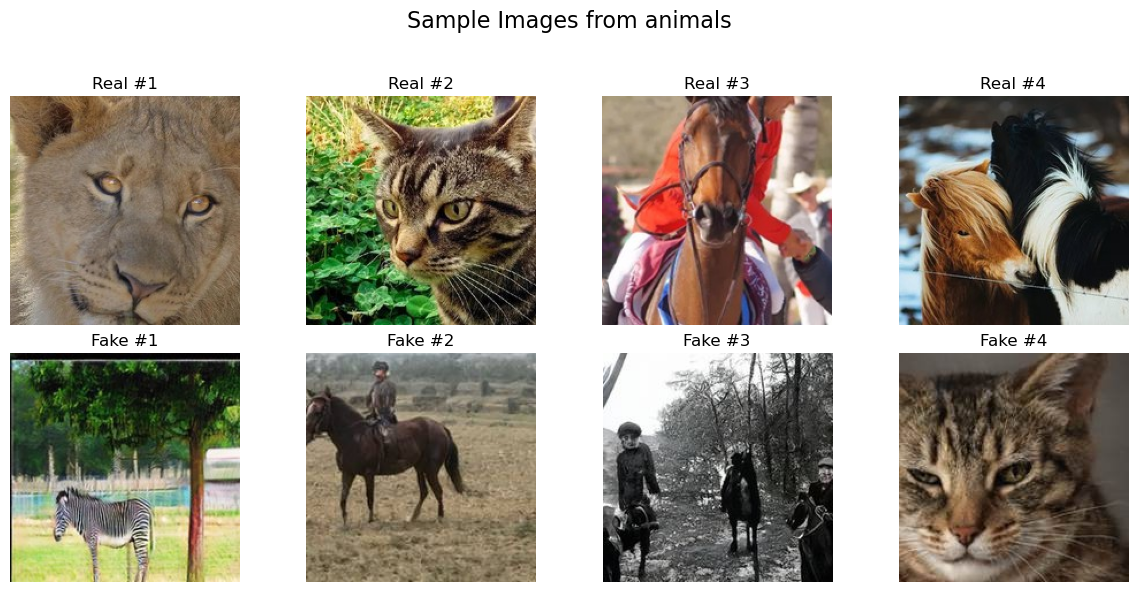

Dataset: faces


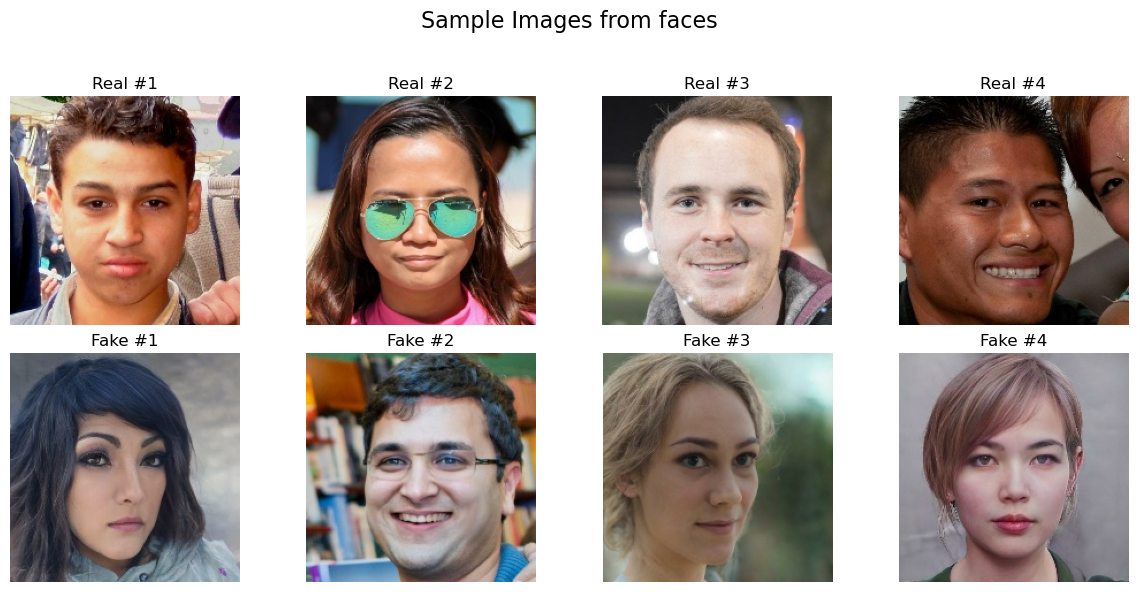

In [30]:
show_sample_images(base_dir, valid_extensions)

### Brighness analysis

In [ ]:
def compute_brightness(image_path: str) -> float | None:
    """compute average brightness of an image"""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)


def collect_brightness_data(
    base_dir: str,
    valid_extensions: set,
    max_images_per_class: int = 5000
) -> pd.DataFrame:
    """traverse dataset and compute brightness for a sample of images"""
    records = []
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if dataset_folder.is_dir():
            dataset_name = dataset_folder.name
            for cls in ['real', 'fake']:
                class_path = dataset_folder / cls
                if class_path.exists():
                    all_images = [
                        img_file for img_file in class_path.iterdir()
                        if img_file.suffix.lower() in valid_extensions
                    ]
                    sampled_images = random.sample(
                        all_images,
                        min(len(all_images), max_images_per_class)
                    )
                    for img_file in sampled_images:
                        brightness = compute_brightness(img_file)
                        if brightness is not None:
                            records.append({
                                "dataset": dataset_name,
                                "class": cls,
                                "brightness": brightness
                            })
    return pd.DataFrame(records)


def plot_brightness_distribution_by_dataset(df: pd.DataFrame):
    """create one subplot per dataset for brightness distribution"""
    datasets = df["dataset"].unique()
    fig, axes = plt.subplots(1, len(datasets), figsize=(18, 5), sharey=True)

    for ax, dataset in zip(axes, datasets):
        subset = df[df["dataset"] == dataset]
        for cls in ['real', 'fake']:
            class_data = subset[subset["class"] == cls]["brightness"]
            ax.hist(class_data, bins=50, alpha=0.6, label=cls)

        ax.set_title(f"{dataset} Dataset")
        ax.set_xlabel("Average arightness")
        ax.legend()

    axes[0].set_ylabel("Frequency")
    fig.suptitle("Brightness distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

  dataset class  brightness
0     art  real   79.958600
1     art  real  113.508100
2     art  real   62.741425
3     art  real  122.994050
4     art  real  112.072375


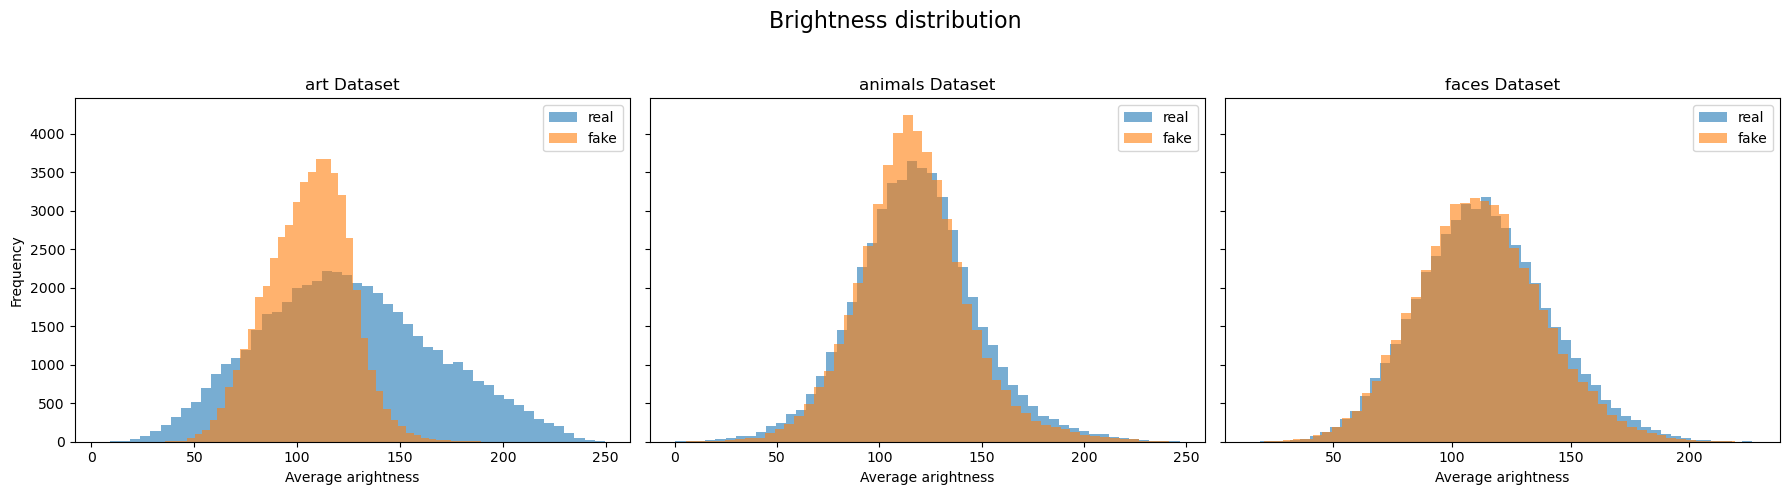

In [20]:
brightness_df = collect_brightness_data(
    base_dir, valid_extensions, MAX_IMAGES_PER_DATASET)
print(brightness_df.head())

plot_brightness_distribution_by_dataset(brightness_df)

### Average color histograms (RGB Channel)

In [ ]:
def compute_mean_rgb(image_path: str) -> tuple[float, float, float] | None:
    """compute average RGB color of an image"""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mean_colors = img_rgb.mean(axis=(0, 1))  
    return tuple(mean_colors)


def collect_mean_rgb_data(
    base_dir: str,
    valid_extensions: set,
    max_images_per_class: int = 5000
) -> pd.DataFrame:
    """traverse dataset and compute mean RGB for a sample of images"""
    records = []
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if dataset_folder.is_dir():
            dataset_name = dataset_folder.name
            for cls in ['real', 'fake']:
                class_path = dataset_folder / cls
                if class_path.exists():
                    all_images = [
                        img_file for img_file in class_path.iterdir()
                        if img_file.suffix.lower() in valid_extensions
                    ]
                    sampled_images = random.sample(
                        all_images,
                        min(len(all_images), max_images_per_class)
                    )
                    for img_file in sampled_images:
                        mean_rgb = compute_mean_rgb(img_file)
                        if mean_rgb is not None:
                            records.append({
                                "dataset": dataset_name,
                                "class": cls,
                                "r": mean_rgb[0],
                                "g": mean_rgb[1],
                                "b": mean_rgb[2],
                            })
    return pd.DataFrame(records)


def plot_rgb_distributions_by_dataset(df: pd.DataFrame):
    """plot RGB mean color distributions per dataset and class"""
    datasets = df["dataset"].unique()
    channels = ['r', 'g', 'b']
    fig, axes = plt.subplots(len(channels), len(
        datasets), figsize=(18, 10), sharey=True)

    for col_idx, dataset in enumerate(datasets):
        subset = df[df["dataset"] == dataset]

        for row_idx, channel in enumerate(channels):
            ax = axes[row_idx, col_idx]
            for cls in ['real', 'fake']:
                class_data = subset[subset["class"] == cls]
                ax.hist(
                    class_data[channel],
                    bins=50,
                    alpha=0.5,
                    label=f'{cls}',
                )
            if row_idx == 0:
                ax.set_title(f"{dataset} Dataset")
            if col_idx == 0:
                ax.set_ylabel(f"{channel.upper()} Intensity")

            ax.set_xlabel("Intensity")
            ax.legend()

    fig.suptitle(
        "RGB Mean Color Distribution by Channel and Dataset", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

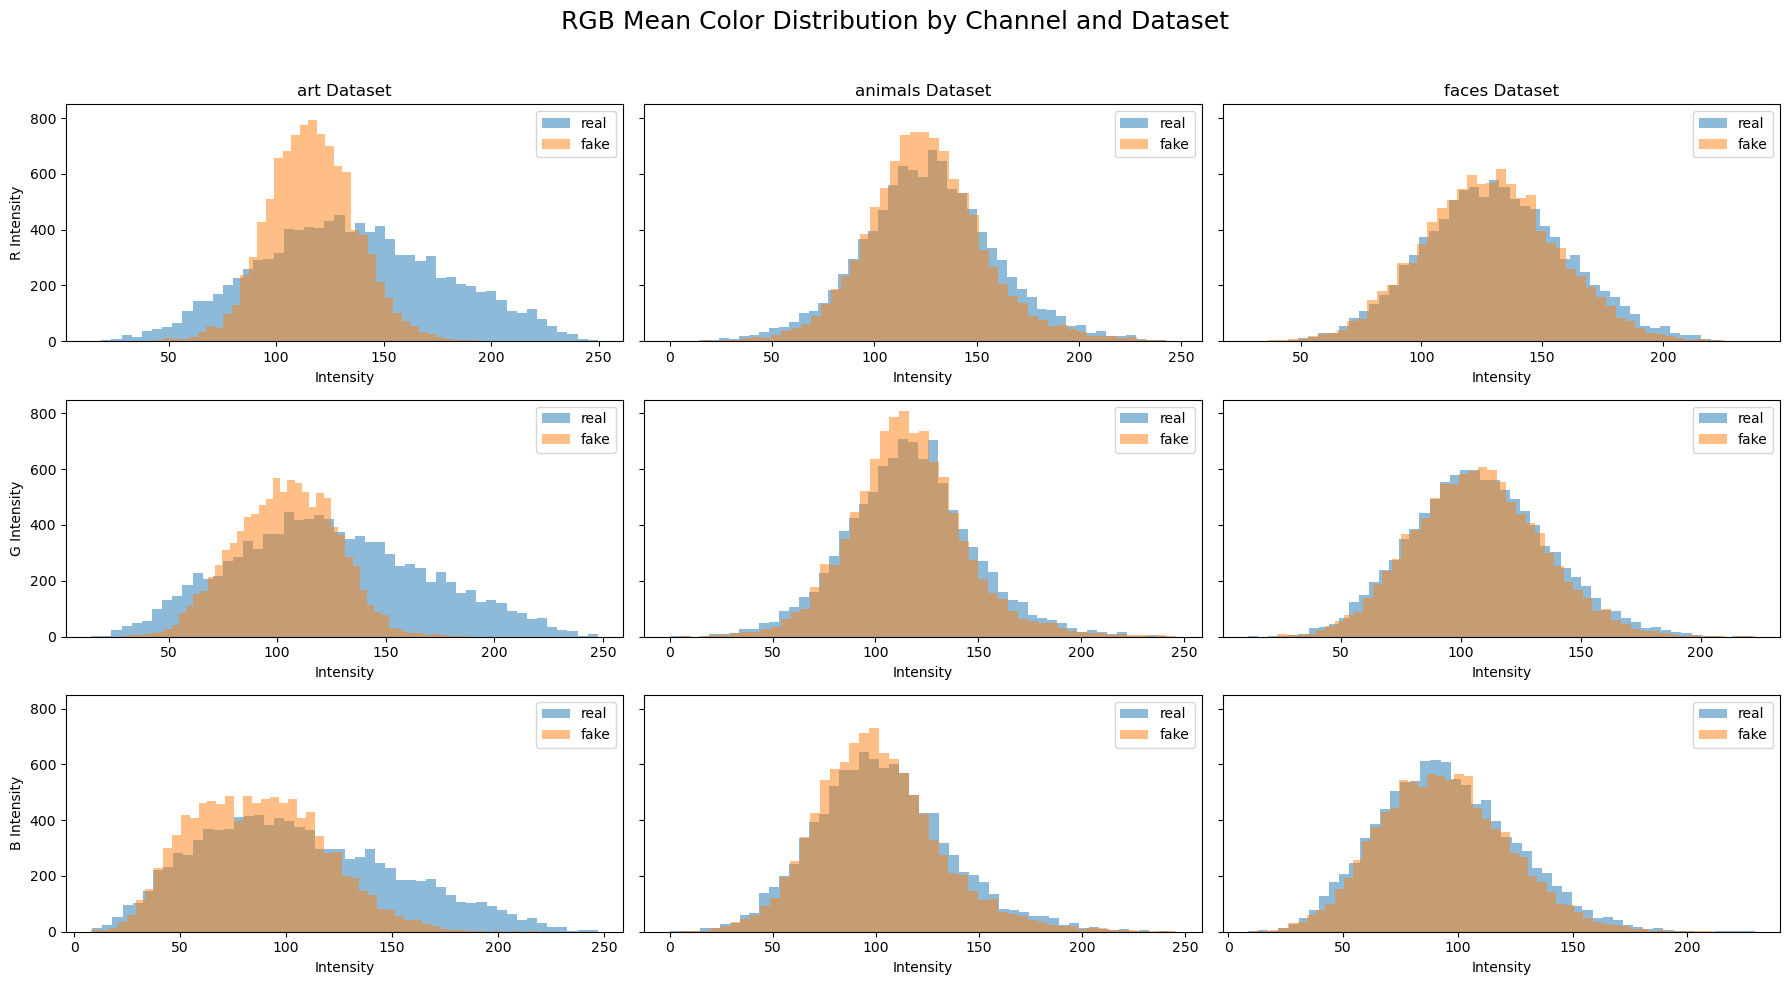

In [10]:
df_rgb = collect_mean_rgb_data(
    base_dir=base_dir,
    valid_extensions=valid_extensions,
    max_images_per_class=MAX_IMAGES_PER_DATASET
)

plot_rgb_distributions_by_dataset(df_rgb)

### Color channel correaltion

In [ ]:
def compute_rgb_correlation(image_path: str) -> np.ndarray | None:
    """compute the correlation matrix of RGB channels in an image"""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    reshaped = img_rgb.reshape(-1, 3)  
    corr_matrix = np.corrcoef(reshaped.T)
    return corr_matrix


def collect_rgb_correlation_data(
    base_dir: str,
    valid_extensions: set,
    max_images_per_class: int = 5000
) -> dict[str, dict[str, np.ndarray]]:
    """traverse dataset and compute average RGB channel correlation matrix per class"""
    results = {}
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if dataset_folder.is_dir():
            dataset_name = dataset_folder.name
            results[dataset_name] = {}

            for cls in ['real', 'fake']:
                class_path = dataset_folder / cls
                if class_path.exists():
                    all_images = [
                        img_file for img_file in class_path.iterdir()
                        if img_file.suffix.lower() in valid_extensions
                    ]
                    sampled_images = random.sample(
                        all_images,
                        min(len(all_images), max_images_per_class)
                    )
                    corr_matrices = []
                    for img_file in sampled_images:
                        corr = compute_rgb_correlation(img_file)
                        if corr is not None:
                            corr_matrices.append(corr)
                    if corr_matrices:
                        avg_corr = np.mean(corr_matrices, axis=0)
                        results[dataset_name][cls] = avg_corr
    return results


def plot_avg_rgb_correlations(corr_data: dict[str, dict[str, np.ndarray]]):
    """plot average RGB channel correlation matrices in a 3x2 grid"""
    datasets = list(corr_data.keys())
    classes = ['real', 'fake']

    fig, axes = plt.subplots(len(datasets), len(classes), figsize=(12, 12))

    for row_idx, dataset_name in enumerate(datasets):
        for col_idx, cls in enumerate(classes):
            ax = axes[row_idx, col_idx]
            matrix = corr_data[dataset_name].get(cls)

            if matrix is not None:
                sns.heatmap(
                    matrix,
                    ax=ax,
                    annot=True,
                    fmt=".2f",
                    cmap="coolwarm",
                    xticklabels=["R", "G", "B"],
                    yticklabels=["R", "G", "B"],
                    cbar=False
                )
                ax.set_title(f"{dataset_name} - {cls}")
            else:
                ax.axis('off')  

    fig.suptitle("Average RGB Channel Correlations", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

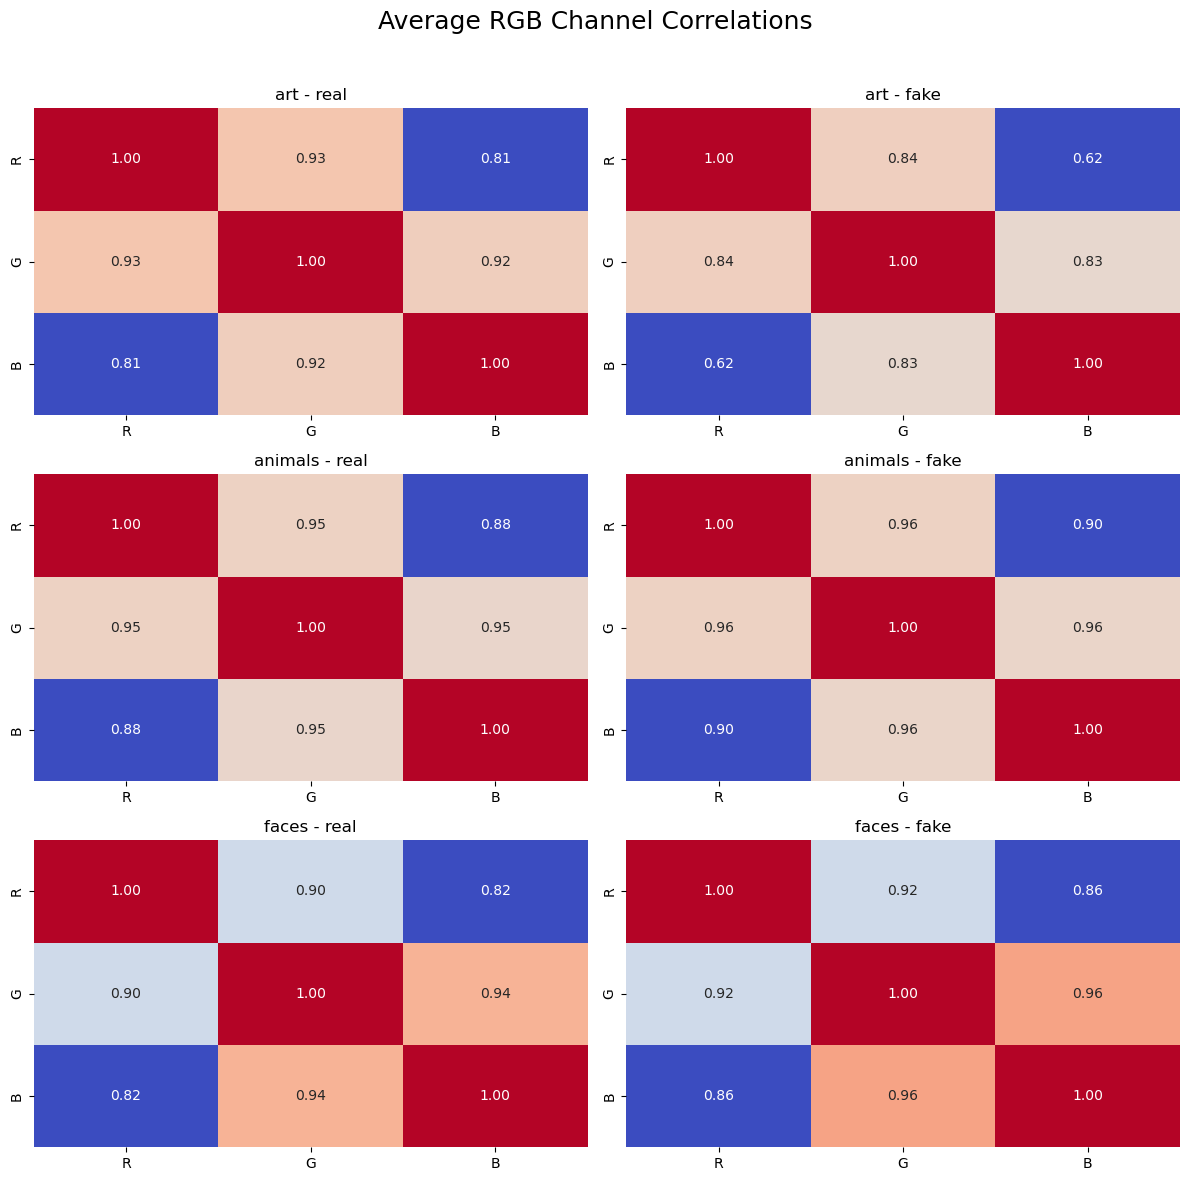

In [12]:
df_cor = collect_rgb_correlation_data(
    base_dir=base_dir,
    valid_extensions=valid_extensions,
    max_images_per_class=MAX_IMAGES_PER_DATASET
)

plot_avg_rgb_correlations(df_cor)

### Bluriness

In [ ]:
def compute_blurriness(image_path: str) -> float | None:
    """compute blurriness using the variance of the Laplacian."""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def collect_blurriness_data(
    base_dir: str,
    valid_extensions: set,
    max_images_per_class: int = 5000
) -> pd.DataFrame:
    """traverse dataset and compute blurriness (Laplacian variance) per image."""
    records = []
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if dataset_folder.is_dir():
            dataset_name = dataset_folder.name
            for cls in ['real', 'fake']:
                class_path = dataset_folder / cls
                if class_path.exists():
                    all_images = [
                        img_file for img_file in class_path.iterdir()
                        if img_file.suffix.lower() in valid_extensions
                    ]
                    sampled_images = random.sample(
                        all_images,
                        min(len(all_images), max_images_per_class)
                    )
                    for img_file in sampled_images:
                        blurriness = compute_blurriness(img_file)
                        if blurriness is not None:
                            records.append({
                                "dataset": dataset_name,
                                "class": cls,
                                "blurriness": blurriness
                            })
    return pd.DataFrame(records)


def plot_blurriness_distribution_by_dataset(df: pd.DataFrame):
    """plot blurriness distribution per dataset in subplots."""
    datasets = df["dataset"].unique()
    fig, axes = plt.subplots(len(datasets), 1, figsize=(
        10, 5 * len(datasets)), sharex=True)

    for ax, dataset in zip(axes, datasets):
        subset = df[df["dataset"] == dataset]
        for cls in ['real', 'fake']:
            class_data = subset[subset["class"] == cls]["blurriness"]
            ax.hist(class_data, bins=40, alpha=0.6, label=cls)
        ax.set_title(f"{dataset} Dataset")
        ax.set_ylabel("Frequency")
        ax.legend()

    axes[-1].set_xlabel("Laplacian Variance (Blurriness)")
    fig.suptitle("Blurriness Distribution by Dataset", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    

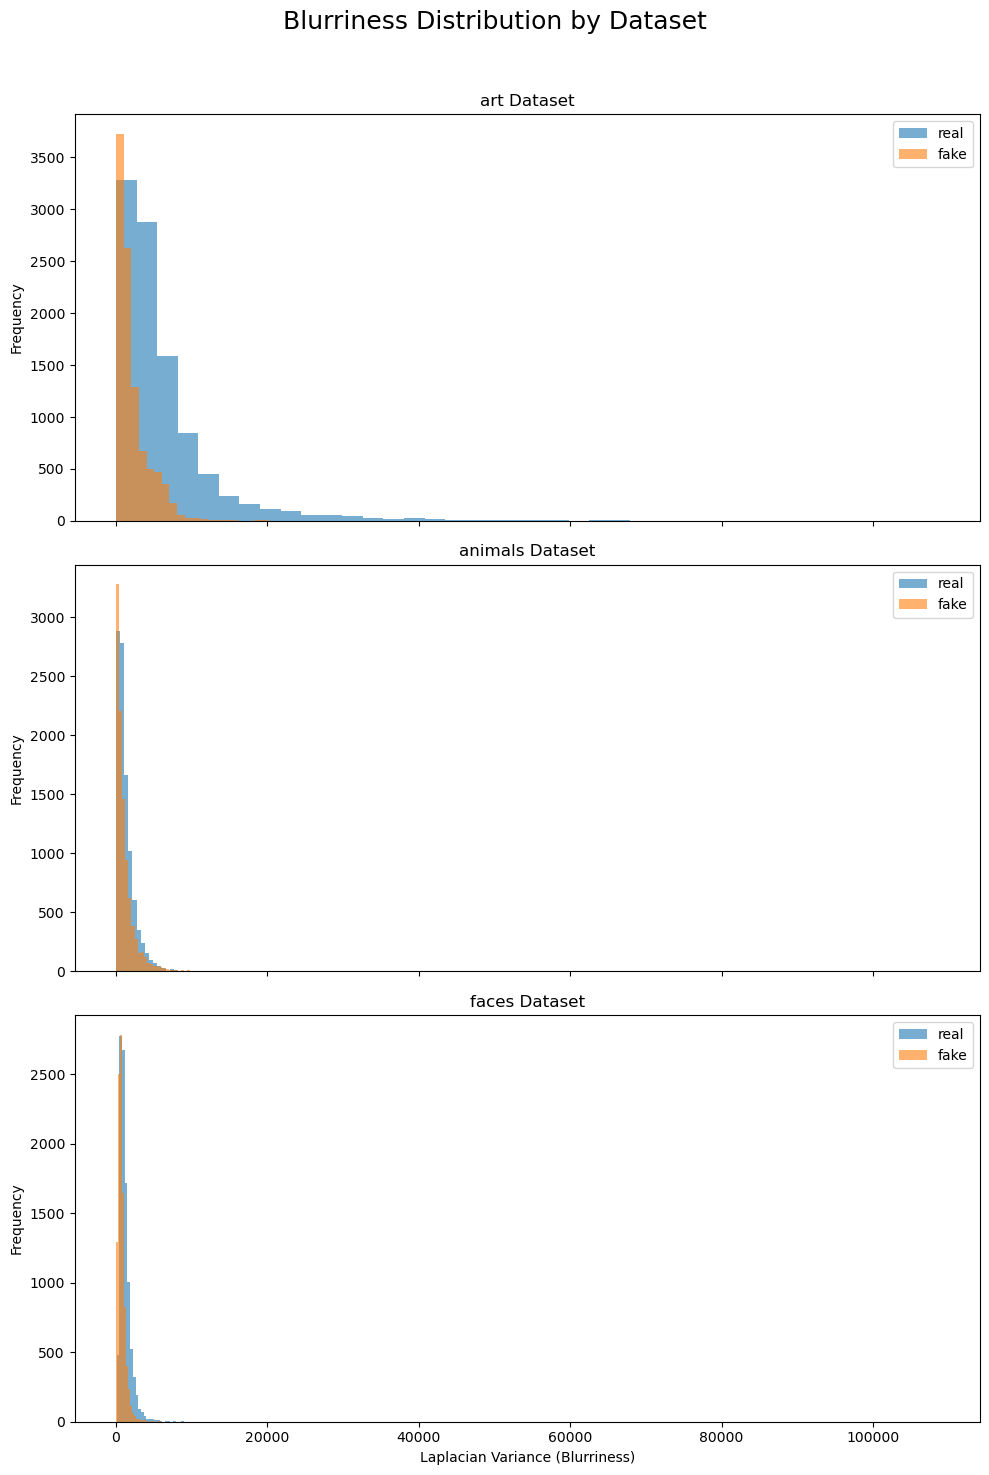

In [14]:
df_blur = collect_blurriness_data(
    base_dir=base_dir,
    valid_extensions=valid_extensions,
    max_images_per_class=MAX_IMAGES_PER_DATASET
)

plot_blurriness_distribution_by_dataset(df_blur)

### Image noise

In [ ]:
def compute_noise(image_path: str) -> float | None:
    """compute image noise as standard deviation of grayscale pixel intensities"""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.std(gray)


def collect_noise_data(
    base_dir: str,
    valid_extensions: set,
    max_images_per_class: int = 5000
) -> pd.DataFrame:
    """traverse dataset and compute noise per image"""
    records = []
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if dataset_folder.is_dir():
            dataset_name = dataset_folder.name
            for cls in ['real', 'fake']:
                class_path = dataset_folder / cls
                if class_path.exists():
                    all_images = [
                        img_file for img_file in class_path.iterdir()
                        if img_file.suffix.lower() in valid_extensions
                    ]
                    sampled_images = random.sample(
                        all_images,
                        min(len(all_images), max_images_per_class)
                    )
                    for img_file in sampled_images:
                        noise = compute_noise(img_file)
                        if noise is not None:
                            records.append({
                                "dataset": dataset_name,
                                "class": cls,
                                "noise": noise
                            })
    return pd.DataFrame(records)


def plot_noise_distribution_by_dataset(df: pd.DataFrame):
    """plot noise distribution per dataset in subplots"""
    datasets = df["dataset"].unique()
    fig, axes = plt.subplots(len(datasets), 1, figsize=(
        10, 5 * len(datasets)), sharex=True)

    if len(datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        subset = df[df["dataset"] == dataset]
        for cls in ['real', 'fake']:
            class_data = subset[subset["class"] == cls]["noise"]
            ax.hist(class_data, bins=40, alpha=0.6, label=cls)
        ax.set_title(f"{dataset} Dataset")
        ax.set_ylabel("Frequency")
        ax.legend()

    axes[-1].set_xlabel("Standard Deviation (Image Noise)")
    fig.suptitle("Noise Distribution by Dataset", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

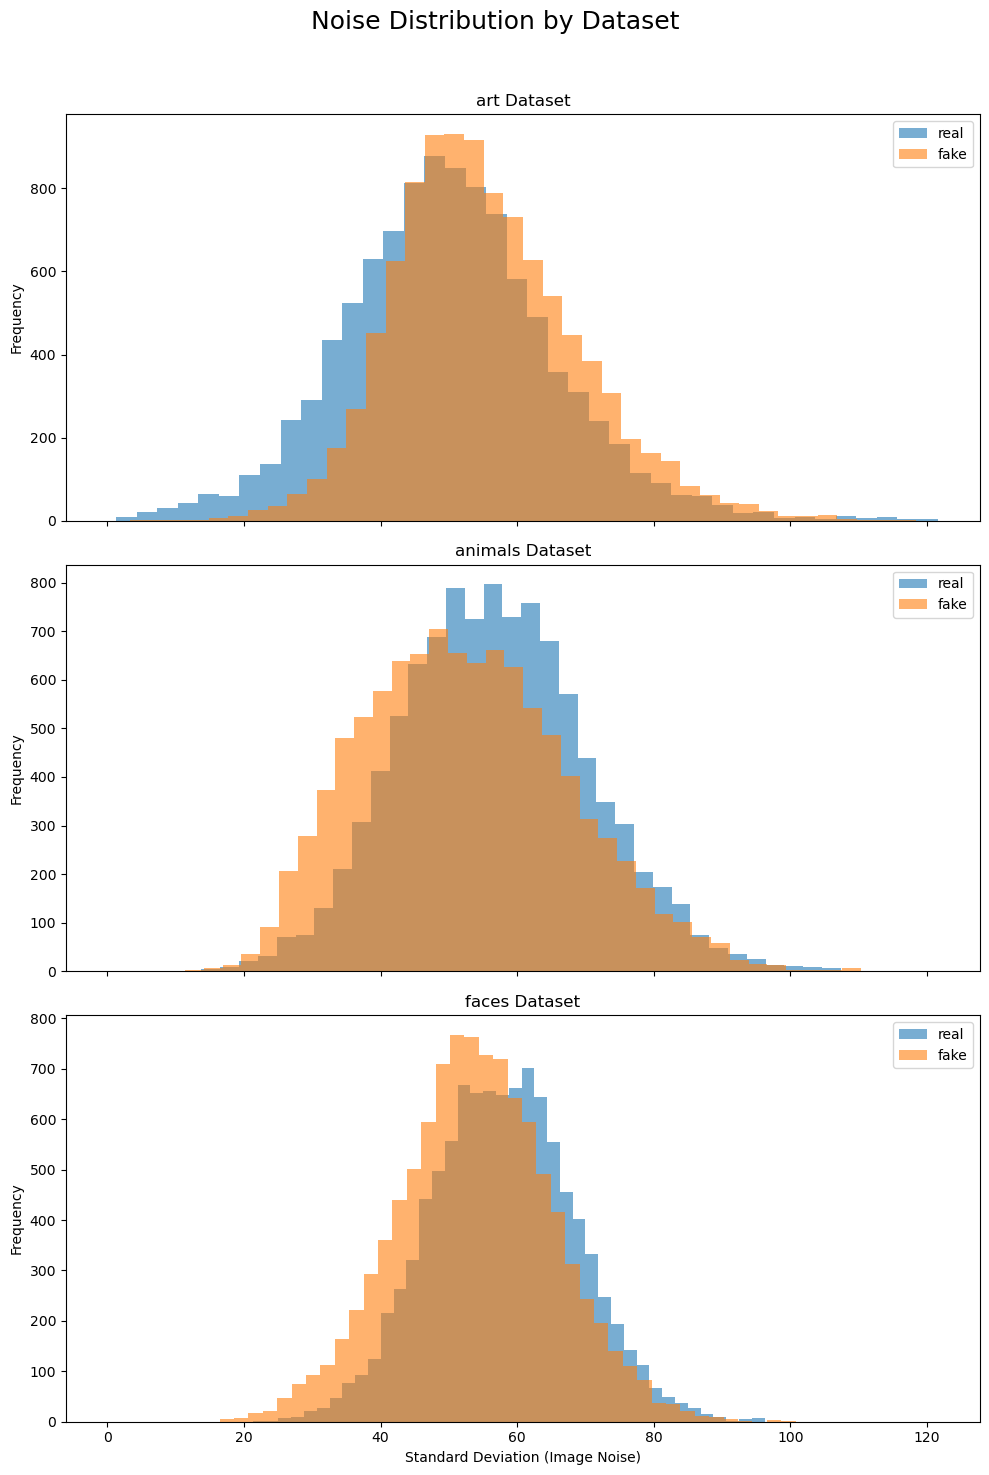

In [16]:
df_noise = collect_noise_data(
    base_dir=base_dir,
    valid_extensions=valid_extensions,
    max_images_per_class=MAX_IMAGES_PER_DATASET
)
plot_noise_distribution_by_dataset(df_noise)

### Edge detection

In [ ]:

def compute_sobel_grad(image_path):
    """compute Sobel gradients for an image"""
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 1.4)

    # sobel operators
    Gx = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(Gx**2 + Gy**2)

    # normalize to range 0-255
    Gx = np.uint8(255 * np.abs(Gx) / np.max(Gx))
    Gy = np.uint8(255 * np.abs(Gy) / np.max(Gy))
    mag = np.uint8(255 * mag / np.max(mag))

    return (Gx, Gy, mag)


def compute_prewitt_grad(image_path):
    """compute Prewitt gradients for an image"""
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # horizontal Prewitt kernel
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]])
    horizontal_edges = cv2.filter2D(gray_image, -1, kernel_x)

    # vertical Prewitt kernel
    kernel_y = np.array([[-1, -1, -1],
                         [0, 0, 0],
                         [1, 1, 1]])
    vertical_edges = cv2.filter2D(gray_image, -1, kernel_y)

    horizontal_edges = np.float32(horizontal_edges)
    vertical_edges = np.float32(vertical_edges)

    gradient_magnitude = cv2.magnitude(horizontal_edges, vertical_edges)

    # highlight edges
    threshold = 50
    _, edges = cv2.threshold(
        gradient_magnitude, threshold, 255, cv2.THRESH_BINARY)

    return edges

def show_edge_visualizations(base_dir: str, valid_extensions: set):
    """for each dataset, display Prewitt edges, Sobel X, Sobel Y, and Sobel magnitude for one real and one fake image"""
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if not dataset_folder.is_dir():
            continue
        dataset_name = dataset_folder.name
        print(f"Processing dataset: {dataset_name}")

        fig, axes = plt.subplots(5, 2, figsize=(10, 10))
        fig.suptitle(f"Edge Features for Dataset: {dataset_name}", fontsize=16)

        for col_idx, cls in enumerate(['real', 'fake']):
            class_path = dataset_folder / cls
            image_files = [f for f in class_path.iterdir(
            ) if f.suffix.lower() in valid_extensions]
            if not image_files:
                continue

            img_path = random.choice(image_files)

            try:
                prewitt = compute_prewitt_grad(str(img_path))
                sobel_x, sobel_y, sobel_mag = compute_sobel_grad(str(img_path))
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
                continue

            # original image
            original_image = cv2.imread(str(img_path))
            original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            
            axes[0, col_idx].imshow(original_image)
            axes[0, col_idx].set_title(f"{cls.capitalize()} - Original Image")

            axes[1, col_idx].imshow(sobel_x, cmap='gray')
            axes[1, col_idx].set_title(f"{cls.capitalize()} - Sobel X")
            axes[2, col_idx].imshow(sobel_y, cmap='gray')
            axes[2, col_idx].set_title(f"{cls.capitalize()} - Sobel Y")
            axes[3, col_idx].imshow(sobel_mag, cmap='gray')
            axes[3, col_idx].set_title(f"{cls.capitalize()} - Sobel Magnitude")
            axes[4, col_idx].imshow(prewitt, cmap='gray')
            axes[4, col_idx].set_title(f"{cls.capitalize()} - Prewitt Edges")

        for ax_row in axes:
            for ax in ax_row:
                ax.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

Processing dataset: art


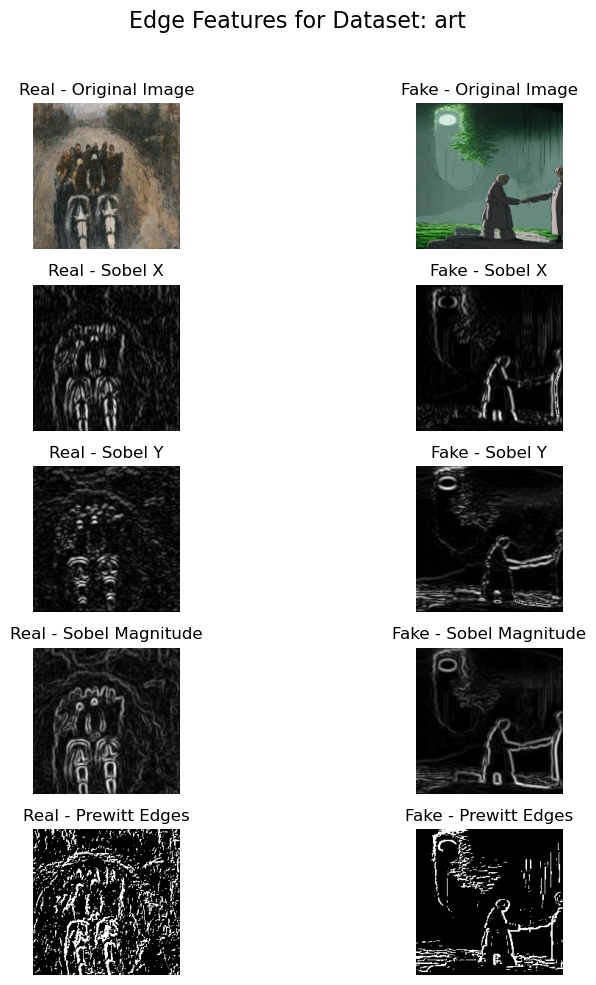

Processing dataset: animals


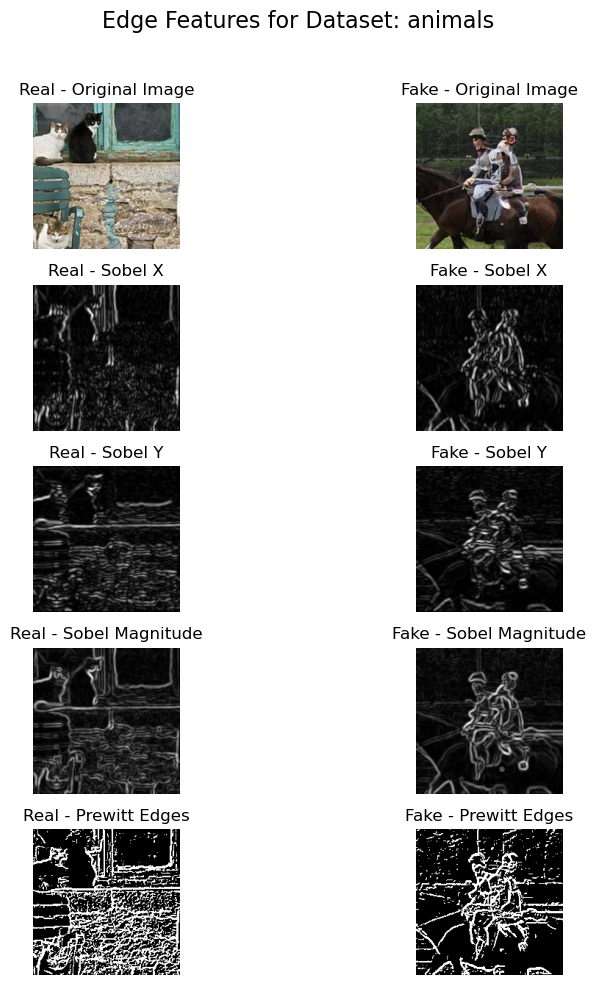

Processing dataset: faces


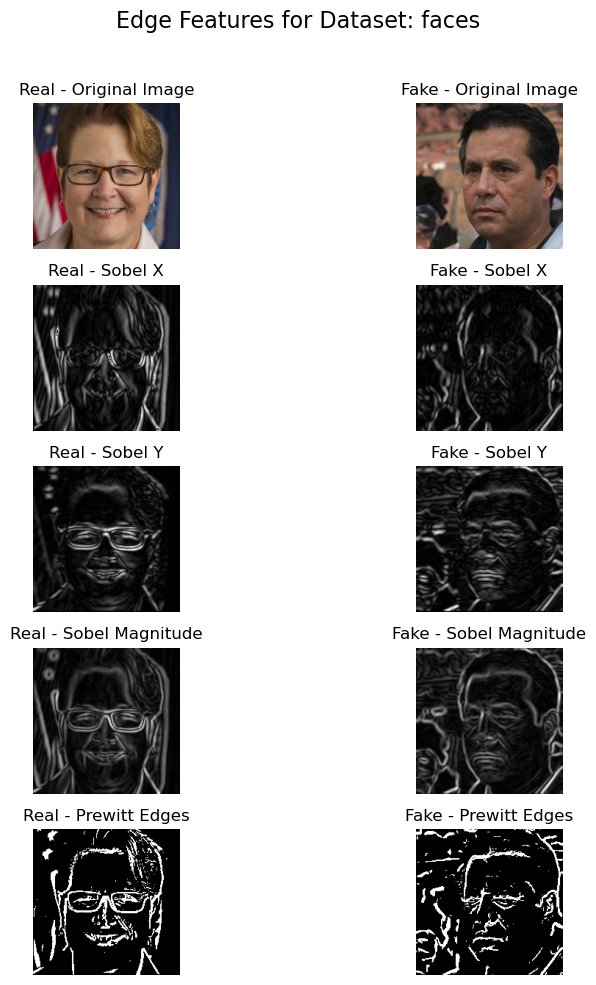

In [28]:
show_edge_visualizations(base_dir, valid_extensions)

### Texture analysis

In [54]:
def compute_glcm(image_path, distances=[5], angles=[0], patch_size=10):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    hei, wid = gray_image.shape
    n_rows, n_cols = hei // patch_size, wid // patch_size

    features = ['contrast', 'dissimilarity',
                'homogeneity', 'energy', 'correlation', 'ASM']
    feature_maps = {f: np.full((n_rows, n_cols), np.nan) for f in features}

    for i in range(n_rows):
        for j in range(n_cols):
            patch = gray_image[i*patch_size:(i+1) *
                               patch_size, j*patch_size:(j+1)*patch_size]
            if patch.shape != (patch_size, patch_size) or patch.std() == 0:
                continue
            try:
                glcm = graycomatrix(
                    patch,
                    distances=distances,
                    angles=angles,
                    levels=256,
                    symmetric=True,
                    normed=True
                )
                for f in features:
                    val = graycoprops(glcm, f)[0, 0]
                    feature_maps[f][i, j] = val
            except Exception:
                continue

    return feature_maps


def show_glcm_feature_maps(base_dir: str, valid_extensions: set, patch_size: int = 10):
    """Show GLCM feature maps + original grayscale image with consistent aspect ratio."""
    features = ['contrast', 'dissimilarity',
                'homogeneity', 'energy', 'correlation', 'ASM']
    base_path = Path(base_dir)

    for dataset_folder in base_path.iterdir():
        if not dataset_folder.is_dir():
            continue
        dataset_name = dataset_folder.name
        print(f"Dataset: {dataset_name}")

        n_rows = len(features) + 1  # +1 for original image
        fig, axes = plt.subplots(n_rows, 2, figsize=(6, 2.2 * n_rows))
        fig.suptitle(f"GLCM Feature Maps - {dataset_name}", fontsize=18)

        for col_idx, cls in enumerate(['real', 'fake']):
            class_path = dataset_folder / cls
            images = [f for f in class_path.iterdir() if f.suffix.lower()
                      in valid_extensions]
            if not images:
                continue

            img_path = random.choice(images)

            try:
                image = cv2.imread(str(img_path))
                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                feature_maps = compute_glcm(img_path, patch_size=patch_size)
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
                continue

            aspect_ratio = gray.shape[0] / gray.shape[1]

            # Original image
            ax = axes[0, col_idx]
            ax.imshow(gray, cmap='gray', aspect=aspect_ratio)
            
            ax.set_title(f"{cls.capitalize()} - original")
            ax.axis('off')

            # Feature maps
            for row_idx, feat in enumerate(features, start=1):
                ax = axes[row_idx, col_idx]
                fmap = feature_maps[feat]
                if fmap.ndim != 2 or fmap.size == 0 or np.all(np.isnan(fmap)):
                    ax.set_title(f"{feat} (Empty)")
                    ax.axis('off')
                    continue

                sns.heatmap(
                    fmap,
                    ax=ax,
                    cmap='viridis',
                    cbar=(col_idx == 1),
                    cbar_kws={'shrink': 0.6},
                    xticklabels=False,
                    yticklabels=False
                )
                ax.set_aspect('equal')  # Match heatmap cell aspect ratio
                if col_idx == 0:
                    ax.set_ylabel(feat.capitalize(), fontsize=10)
                if row_idx == 1:
                    ax.set_title(f"{cls.capitalize()}")


        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

Dataset: art


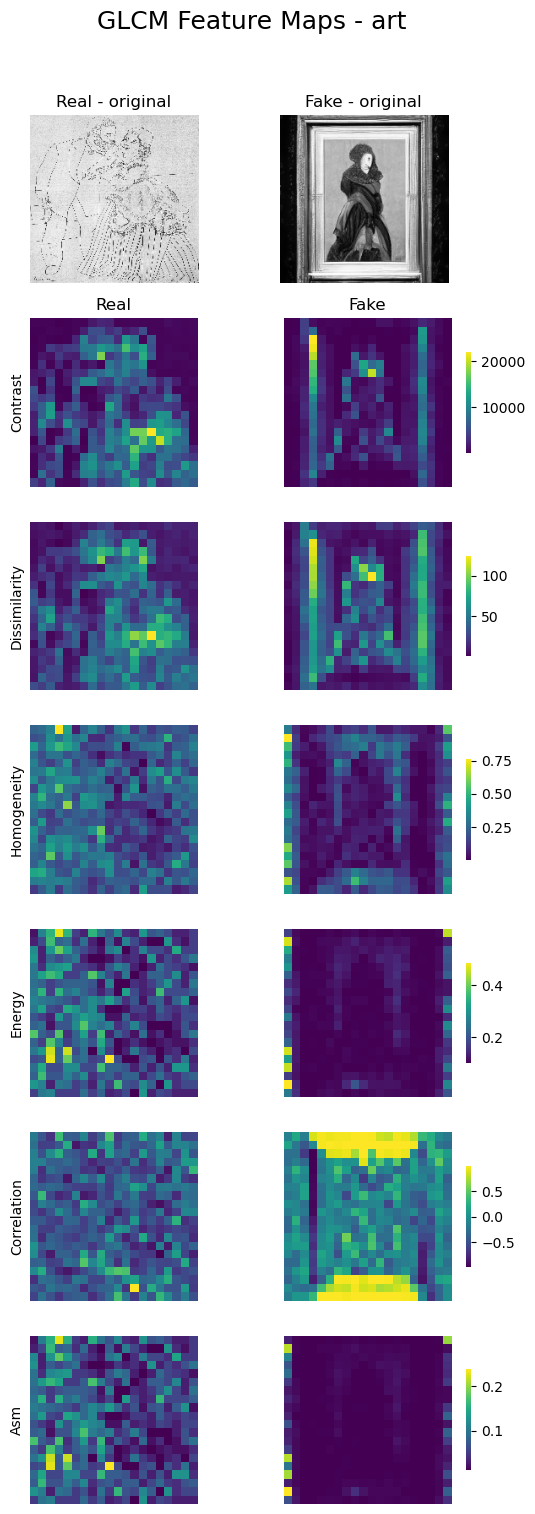

Dataset: animals


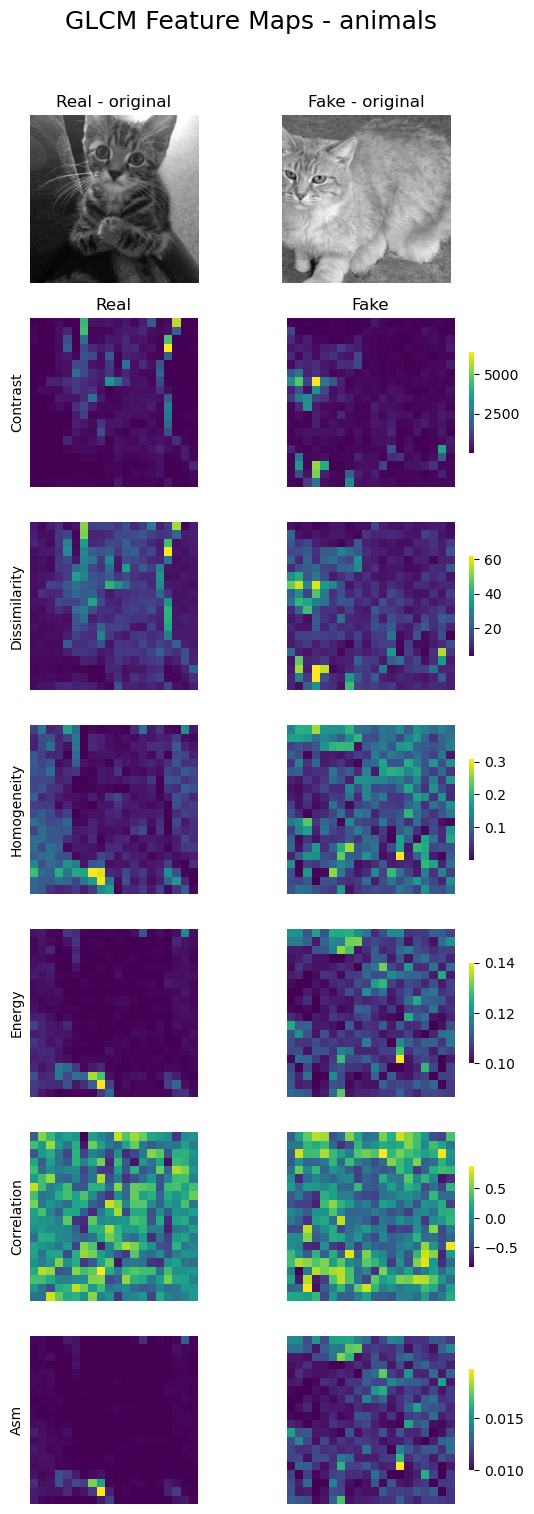

Dataset: faces


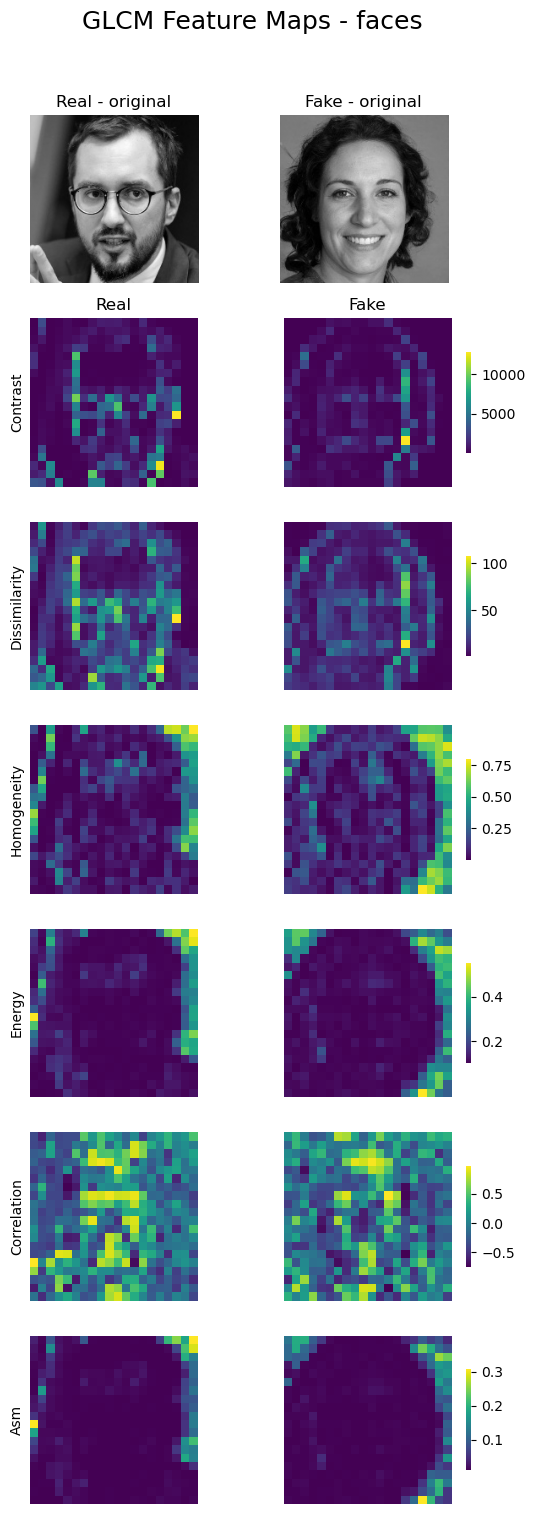

In [55]:
show_glcm_feature_maps(base_dir, valid_extensions, patch_size=10)

### Clustering

In [ ]:
def load_images_from_dir(directory, label, target_size=(200, 200), max_images=2500):
    images = []
    labels = []
    count = 0
    for fname in tqdm(os.listdir(directory), desc=f"Loading {label}"):
        if count >= max_images:
            break
        try:
            path = os.path.join(directory, fname)
            img = load_img(path, target_size=target_size)
            img_array = img_to_array(img)
            img_array = preprocess_input(img_array)
            images.append(img_array)
            labels.append(label)
            count += 1
        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue
    return np.array(images), np.array(labels)


def process_dataset(dataset_path: Path, max_images=5000):
    """load images from the dataset, extract features using ResNet50, and apply t-SNE and KMeans clustering"""
    real_dir = dataset_path / "real"
    fake_dir = dataset_path / "fake"
    if not real_dir.exists() or not fake_dir.exists():
        return


    X_real, y_real = load_images_from_dir(
        real_dir, 0, max_images=max_images // 2)
    X_fake, y_fake = load_images_from_dir(
        fake_dir, 1, max_images=max_images // 2)

    X = np.concatenate([X_real, X_fake])
    y = np.concatenate([y_real, y_fake])

    model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    features = model.predict(X, batch_size=32, verbose=1)

    print("applying t-SNE...")
    tsne = TSNE(n_components=3, perplexity=30, random_state=42)
    X_3d = tsne.fit_transform(features)

    print("running KMeans clustering...")
    kmeans = KMeans(n_clusters=2, random_state=42)
    clusters = kmeans.fit_predict(X_3d)

    fig = plt.figure(figsize=(20, 8))
    centroids = kmeans.cluster_centers_

    # === Left: True Labels ===
    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                        c=y, cmap='coolwarm', alpha=0.7)

    ax1.set_title(f"{dataset_path.name} - True Labels (Real vs Fake)", fontsize=14)
    ax1.set_xlabel("t-SNE Dim 1")
    ax1.set_ylabel("t-SNE Dim 2")
    ax1.set_zlabel("t-SNE Dim 3")

    legend_labels = ['Real', 'Fake']
    legend_colors = ['blue', 'red']
    legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                                label=lbl, markerfacecolor=col, markersize=10)
                    for lbl, col in zip(legend_labels, legend_colors)]
    ax1.legend(handles=legend_handles, title="Class")

    # === Right: Predicted Clusters ===
    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                        c=clusters, cmap='viridis', alpha=0.7)
    ax2.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                s=300, c='black', marker='X', label='Centroids')

    ax2.set_title(f"{dataset_path.name} - KMeans Clustering", fontsize=14)
    ax2.set_xlabel("t-SNE Dim 1")
    ax2.set_ylabel("t-SNE Dim 2")
    ax2.set_zlabel("t-SNE Dim 3")
    
    legend_labels = ['Cluster 0', 'Cluster 1']

    ax2.legend(title="Cluster Info")
    plt.tight_layout()
    plt.show()

Loading 1:   8%|▊         | 5000/61322 [00:03<00:39, 1433.68it/s]


313/313 ━━━━━━━━━━━━━━━━━━━━ 268s 848ms/step
applying t-SNE...
running KMeans clustering...


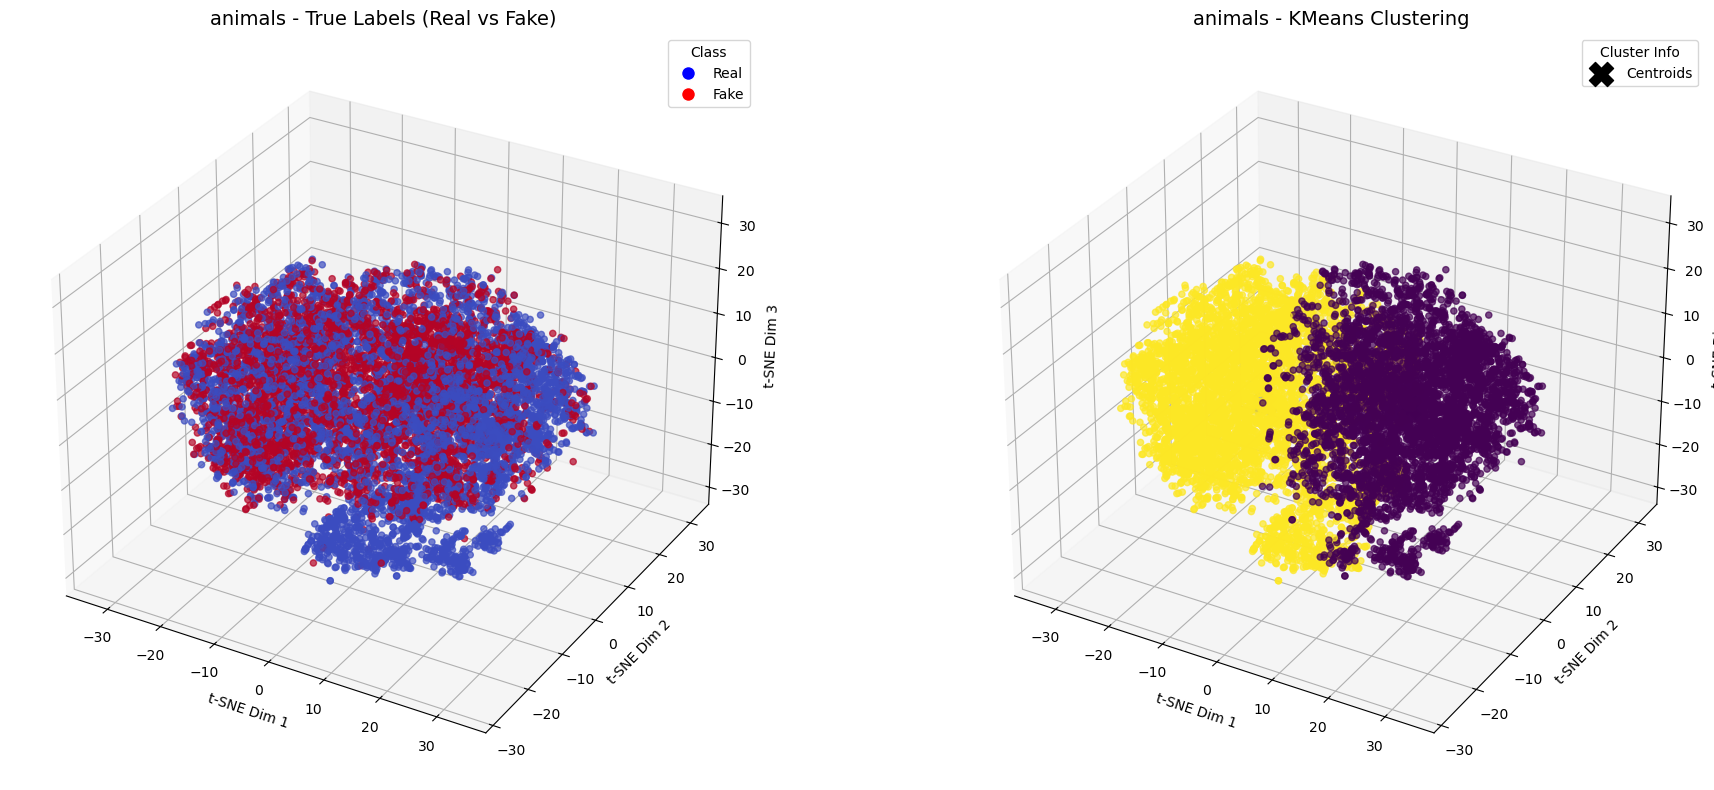

Loading 1:   8%|▊         | 5000/59465 [00:03<00:39, 1386.15it/s]


313/313 ━━━━━━━━━━━━━━━━━━━━ 264s 836ms/step
applying t-SNE...
running KMeans clustering...


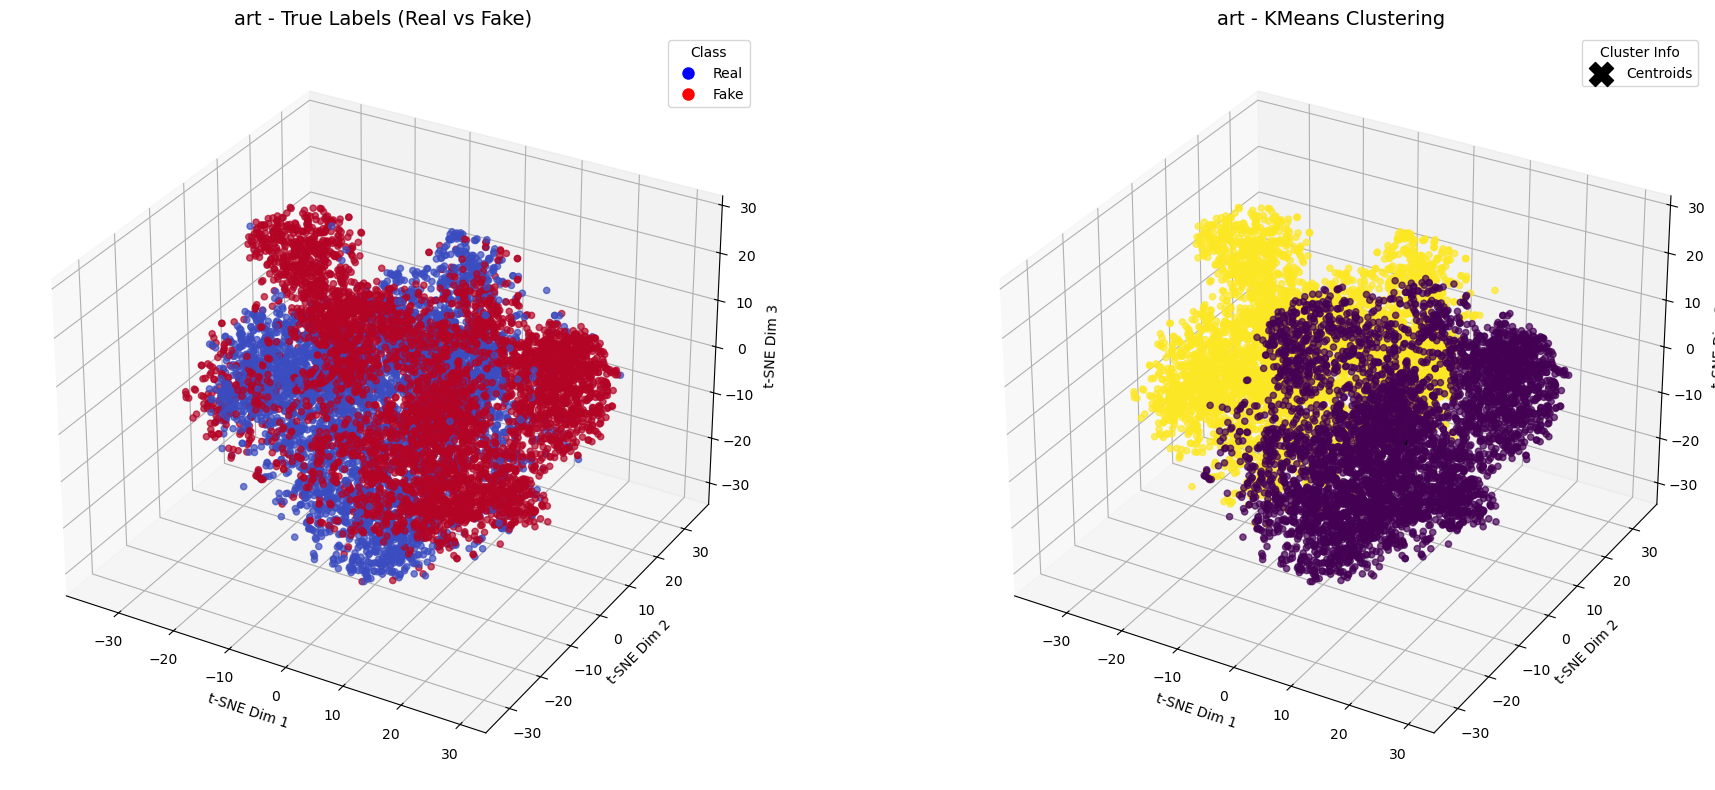

Loading 1:  10%|▉         | 5000/50959 [00:03<00:33, 1385.98it/s]


313/313 ━━━━━━━━━━━━━━━━━━━━ 270s 852ms/step
applying t-SNE...
running KMeans clustering...


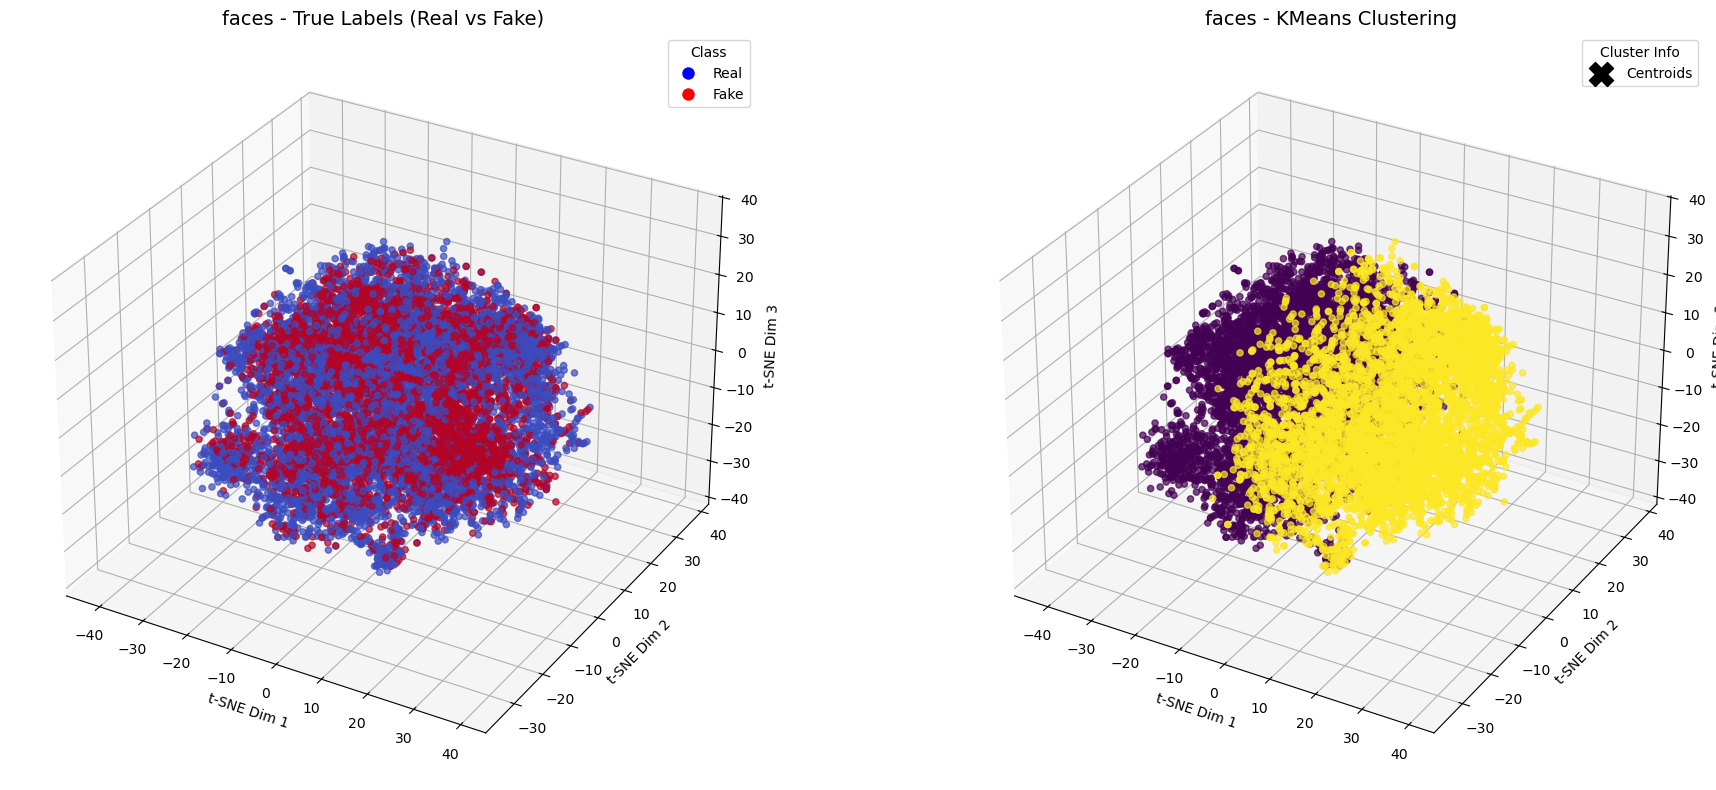

In [64]:
path = Path(base_dir)
for dataset_folder in sorted(path.iterdir()):
    if dataset_folder.is_dir():
        process_dataset(dataset_folder, max_images=10000)